# Setup & Imports

In this notebook we present the training and evaluation of a Logistic Regression model on the preprocessed dataset of tennis matches, described previously in `src/notebooks/preprocessing.ipynb`. 

The document is structured as follows:
- **Setup & Imports**: we import the necessary libraries and modules, and build the preprocessing pipeline.
- **Training & Fine-tuning**: we train the model and perform hyperparameter tuning
- **Evaluation**: we evaluate the model on the test set and analyze the results.

In [32]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent 
sys.path.append(str(PROJECT_ROOT))

from typing import cast

from src.data.loader import load_data, train_test_split
from src.data.preprocess import preprocessing_pipeline, create_labels
from src.data.transformers import DropFeatureSelector
from src.features.features import feature_engineering_pipeline
from src.training.training import training_pipeline, fine_tune, feature_selection_pipeline
from src.evaluation.metrics import feature_importance, cross_validation, evaluation_metrics, print_metrics
from src.evaluation.plots import plot_feature_importance, plot_roc_curve, plot_confusion_matrix
from src.utils.utils import get_best_estimator, TSCV

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [33]:
df = load_data()
create_labels(df)
X_train, X_test, y_train, y_test = train_test_split(df)
prep_pipeline : Pipeline = preprocessing_pipeline(X_train, y_train)
feat_pipeline : Pipeline = feature_engineering_pipeline()

preprocessor = Pipeline(
    steps=[
        ("preprocessing", prep_pipeline),
        ("feature_engineering", feat_pipeline),
        ("standard_scaler", StandardScaler())
    ]
)

# Training & Fine Tuning

Firstly, we add the Logistic Regression Classifier as a step for the pipeline, then the we perform the fine tuning of the hyperparameters using a `RandomizedSearchCV` with 5-fold.  

In [34]:
log_reg_train_pipeline = training_pipeline(model=LogisticRegression(random_state=42))

pipeline = Pipeline(
        steps = preprocessor.steps + log_reg_train_pipeline.steps
    )

hyperparams = [
    {
        "training__solver": ["liblinear"],
        "training__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "training__l1_ratio": [0, 1],    
        "training__class_weight": [None, "balanced"],
        "training__max_iter": [500, 1000, 2000],
    },
    {
        "training__solver": ["saga"],
        "training__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "training__l1_ratio": [0, 1],    
        "training__class_weight": [None, "balanced"],
        "training__max_iter": [500, 1000, 2000],
    },
]

search_log_reg = fine_tune(
    pipeline=pipeline,
    tuning_methods=RandomizedSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    random_state=42,
    verbose=0,
)

search_log_reg.fit(X_train, y_train)

/Users/chetto/Desktop/Uni/ANNO-III/AI/Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/chetto/Desktop/Uni/ANNO-III/AI/Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/chetto/Desktop/Uni/ANNO-III/AI/Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'training__C': [0.001, 0.01, ...], 'training__class_weight': [None, 'balanced'], 'training__l1_ratio': [0, 1], 'training__max_iter': [500, 1000, ...], ...}, {'training__C': [0.001, 0.01, ...], 'training__class_weight': [None, 'balanced'], 'training__l1_ratio': [0, 1], 'training__max_iter': [500, 1000, ...], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` whil

We derive the best estimator from the search, and we validate the model using cross-validation on the training set.

In [35]:
best_estimator = get_best_estimator(search_log_reg)
best_estimator.steps[-1]

('training',
 LogisticRegression(C=1, class_weight='balanced', l1_ratio=1, max_iter=500,
                    random_state=42, solver='saga'))

In [36]:
cross_val_scores = cross_validation(
        pipeline=best_estimator,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

/Users/chetto/Desktop/Uni/ANNO-III/AI/Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


count    5.000000
mean     0.669939
std      0.011507
min      0.652674
25%      0.664861
50%      0.673324
75%      0.676710
max      0.682126
dtype: float64


The classifier demonstrated moderate classification performance, achieving an average accuracy of around 67% across five cross-validation folds. 
Its low standard deviation suggests that the model's performance is stable and relatively insensitive to the particular dataset on which it was trained.

## Feature Selection

The feature set generated after preprocessing contains many columns, some of which are redundant or weakly related to the target outcome. Thus, we can perform feature selection before the final Logistic Regression training, to improve generalization on unseen matches, reducing the noise and model complexity. 
Moreover, this method helps identify which tennis statistics are most informative for predicting the winner.

Initially, we extract the feature importance scores from the tuned Logistic Regression model. 

In [37]:
importances = feature_importance(
    pipeline=best_estimator,
    X=X_train,
    model_step="training",
    coef=True
)

importances

,importance
Tournament_Wimbledon,0.098015
last_k_games_win_rate_diff,0.092451
Tournament_Mercedes Cup,0.065605
sets_h2h_diff,0.064968
Tournament_Ricoh Open,0.054203
...,...
h2h_court_diff,-0.061563
rank_diff,-0.069902
weighted_pts_diff,-0.104113
Surface_Grass,-0.133904


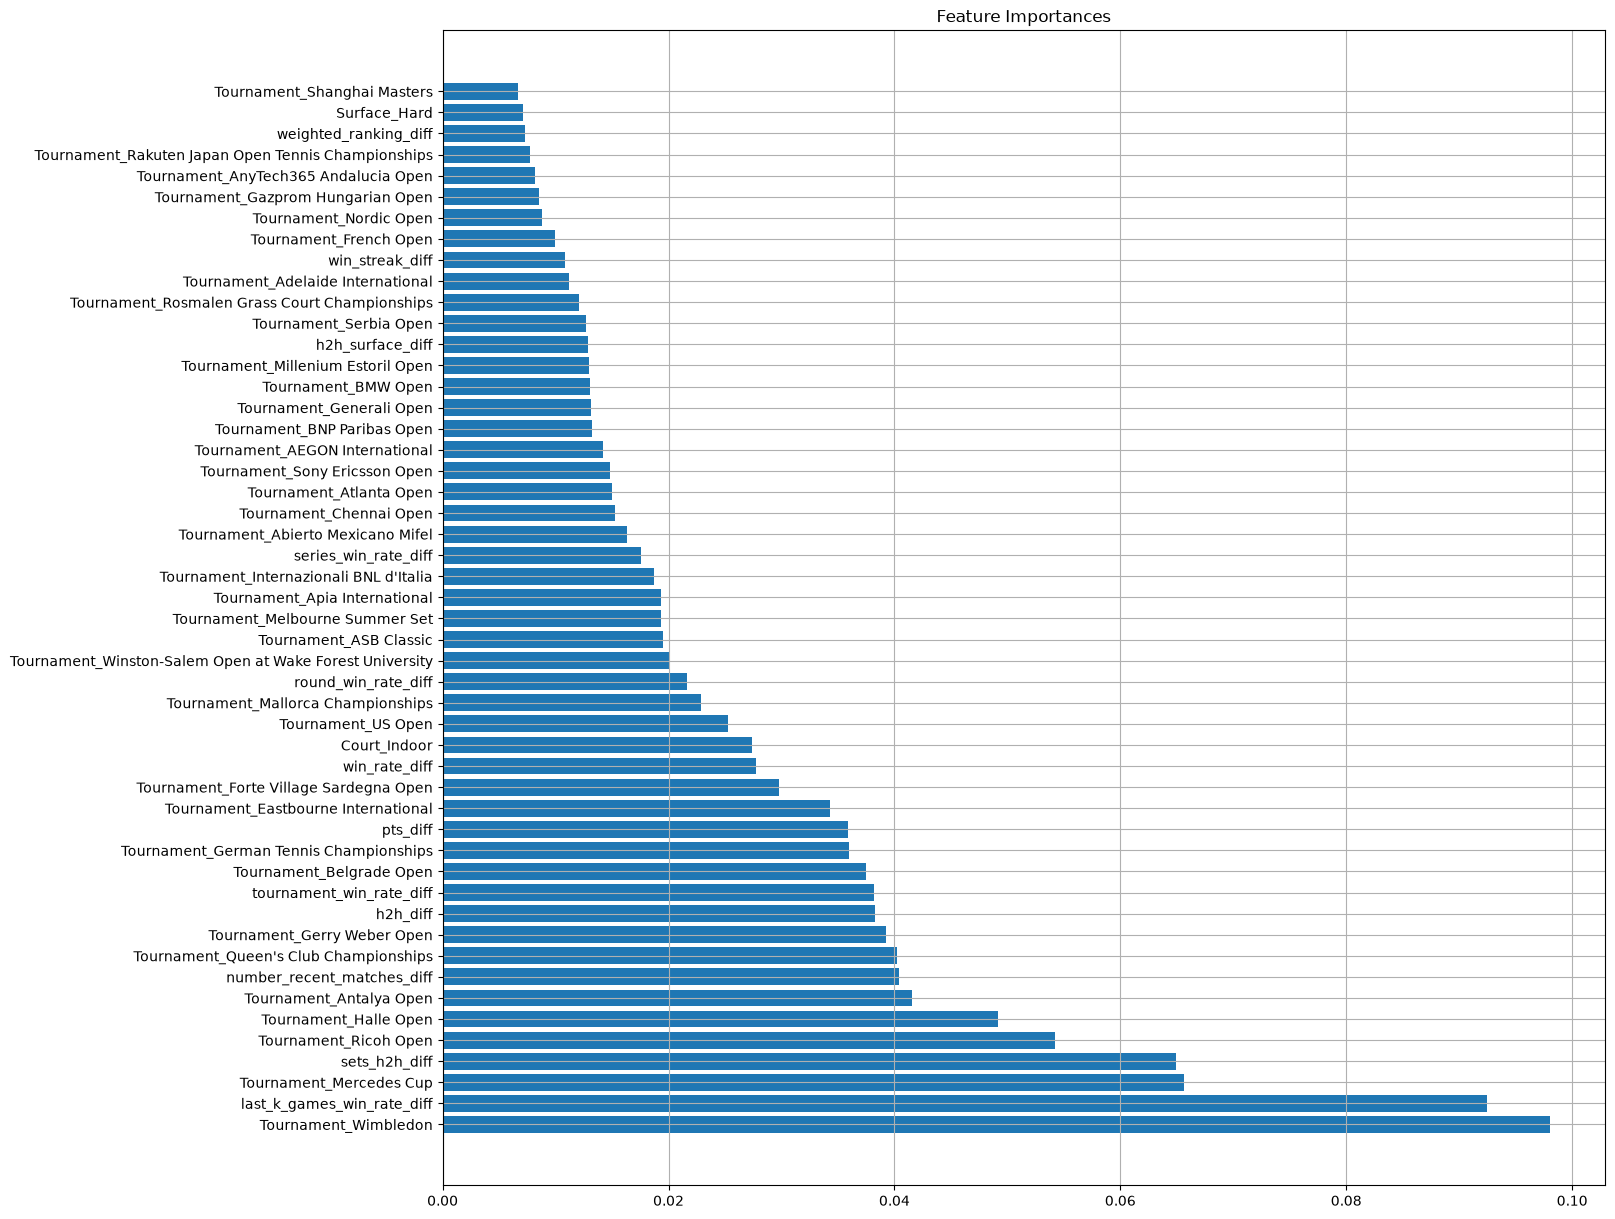

In [38]:
plot_feature_importance(
    feature_names=importances.index.tolist(),
    feature_importances=importances["importance"],
    top_n=50
)

The feature importance scores cleary show that the tournaments ohe columns are very relevant for the model. Therefore we can try to simplify the model by performing `RFECV` (`Recursive Feature Elimination with Cross-Validation`) to find the best subset of features for describing the target variable.

In [ ]:
rcevf_pipeline = feature_selection_pipeline(
    model=LogisticRegression(random_state=42),
    tscv=TSCV,
    min_features_to_select=20,
)

pipeline = Pipeline(
    steps= preprocessor.steps + [
                ("fs", rcevf_pipeline),
            ] + log_reg_train_pipeline.steps
    )

search_log_reg = fine_tune(
    pipeline=pipeline,
    tuning_methods=RandomizedSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    verbose=0,
    random_state=42
)

search_log_reg.fit(X_train, y_train)

In [40]:
best_estimator = get_best_estimator(search_log_reg)
best_estimator.steps[-1]

('training',
 LogisticRegression(C=0.01, l1_ratio=0, max_iter=500, random_state=42,
                    solver='liblinear'))

In [41]:
cross_val_scores = cross_validation(
        pipeline=best_estimator,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

count    5.000000
mean     0.673595
std      0.009792
min      0.659106
25%      0.668246
50%      0.678064
75%      0.679418
max      0.683142
dtype: float64


The accuracy of the model obtained with cross-validation is similar to the previous one, thus we can choose the model with less features.

Therefore, for evaluation we will use the best estimator obtained from the feature selection pipeline, so we define the full pipeline as follows:

In [42]:
full_pipeline_lr = best_estimator

# Evaluation

We evaluate the full pipeline on the test set.

In [43]:
y_pred = full_pipeline_lr.predict(X_test)

In [44]:
metrics : dict = evaluation_metrics(
    model=full_pipeline_lr,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred
)

print_metrics(metrics)


Accuracy:
0.6794

Roc Auc:
0.7393

F1:
0.6748

Recall:
0.6837

Confusion Matrix:
      0     1
0  1548   744
1   687  1485


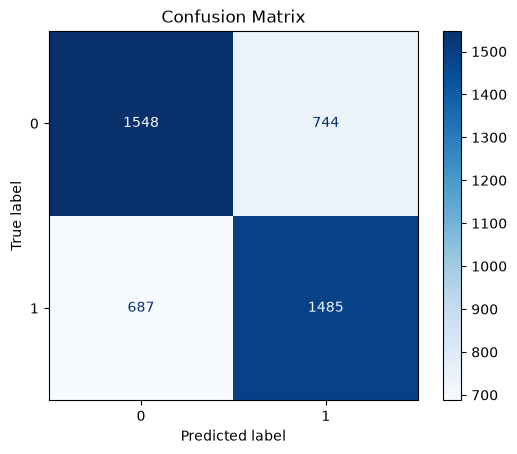

In [45]:
plot_confusion_matrix(cm=metrics["confusion_matrix"])

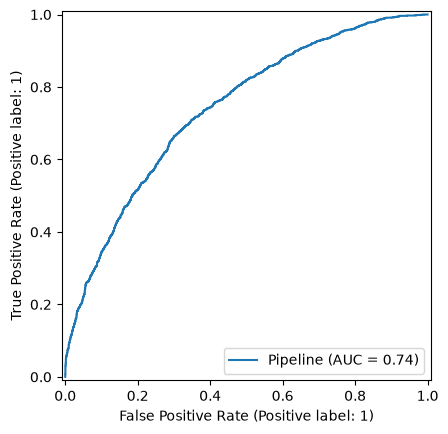

In [46]:
plot_roc_curve(
    model=full_pipeline_lr,
    X_test=X_test,
    y_test=y_test
)

Recall that the task is a binary classification problem with two players, thus, the goal of the model should be to predict correctly the most amount of matches outcome.
Therefore the main metrics to evaluate the generalization of the model are accuracy and roc-auc:
- The accuracy of the model on unseen matches is nearly 68%, which is similar to the accuracy obtained during validation.
- The roc-auc score obtained reached roughly 0.74.
- The confusion matrix shows that the model does not favor any player, since the difference between the number of false positives and false negatives is not significant.

### Incorrectly Predicted Matches

In conclusion, we investigate the distribution of wrongly predicted matches.

Recall that, in a Logistic Regression model, the sign of a feature's coefficient determines the direction of its relationship with the target variable:
- Positive, means that the feature is positively correlated with the target variable, making the target value more likely to be 1 (i.e. player_1 wins)
- Negative, means that the feature is negatively correlated with the target variable, making the target value more likely to be 0 (i.e. player_2 wins)
- Zero, the feature has no effect on the model's prediction.

In [47]:
X_test_transformed = full_pipeline_lr[:-1].transform(X_test)

coefficients = pd.DataFrame({
    "Feature": X_test_transformed.columns,
    "Coefficient": full_pipeline_lr[-1].coef_[0]
})

print(coefficients)   

                                   Feature  Coefficient
0      Tournament_Adelaide International 1    -0.038568
1                 Tournament_Belgrade Open     0.036517
2                  Tournament_Estoril Open    -0.031640
3   Tournament_German Tennis Championships     0.034611
4                    Tournament_Korea Open    -0.042260
5                    Tournament_Ricoh Open     0.030771
6                                 pts_diff     0.081699
7                        weighted_pts_diff    -0.086847
8                                rank_diff    -0.082598
9                            sets_h2h_diff     0.089640
10                            max_bet_diff    -0.706156
11                            avg_bet_diff    -0.659221
12            last_k_matches_win_rate_diff    -0.024149
13      last_k_matches_rank_variation_diff    -0.046063
14                tournament_win_rate_diff     0.043018
15                       h2h_weighted_diff    -0.031601
16                          h2h_court_diff    -0

In [48]:
wrong = np.asarray(y_pred) != np.asarray(y_test)
X_test_transformed = full_pipeline_lr[:-1].transform(X_test)
errors = X_test_transformed.loc[wrong].copy()
errors["y_true"] = np.asarray(y_test)[wrong]
errors["y_pred"] = np.asarray(y_pred)[wrong]
# errors["proba_pos"] = full_pipeline_rf.predict_proba(X_test)[:, 1]

# false positives vs false negatives
player2_wins_wrong_pred = errors[(errors.y_true == 0) & (errors.y_pred == 1)] # player_2 actually won
player1_wins_wrong_pred = errors[(errors.y_true == 1) & (errors.y_pred == 0)] # player_1 actually won

player2_wins_wrong_pred.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Tournament_Adelaide International 1,744.0,-0.057292,2.083069e-17,-0.057292,-0.057292,-0.057292,-0.057292,-0.057292
Tournament_Belgrade Open,744.0,0.453395,3.553092e+00,-0.038324,-0.038324,-0.038324,-0.038324,26.093029
Tournament_Estoril Open,744.0,-0.055275,0.000000e+00,-0.055275,-0.055275,-0.055275,-0.055275,-0.055275
Tournament_German Tennis Championships,744.0,-0.083586,1.388712e-17,-0.083586,-0.083586,-0.083586,-0.083586,-0.083586
Tournament_Korea Open,744.0,-0.038324,6.943562e-18,-0.038324,-0.038324,-0.038324,-0.038324,-0.038324
Tournament_Ricoh Open,744.0,-0.055275,6.943562e-18,-0.055275,-0.055275,-0.055275,-0.055275,-0.055275
pts_diff,744.0,0.390337,6.350520e-01,-1.594640,0.018953,0.208221,0.606356,4.323063
weighted_pts_diff,744.0,0.139195,5.166213e-01,-0.254323,0.003797,0.008664,0.055758,6.394942
rank_diff,744.0,-0.346664,7.976887e-01,-5.994740,-0.465859,-0.204045,-0.026081,5.887820
sets_h2h_diff,744.0,0.261964,1.189955e+00,-3.943356,0.002114,0.002114,0.495298,7.399871


Excluding the tournament OHE features, which are difficult to interpret, we can analyze the distribution of feature values for the incorrectly predicted matches, i.e., matches in which Player 2 was the actual winner.

For example, considering the features in order of importance and evaluating their contributions using the median feature values, we observe that:

- $\beta_{\text{last\_k\_games\_win\_rate\_diff}} \cdot \text{last\_k\_games\_win\_rate\_diff} > 0$. Therefore, the contribution of this feature favors Player 1, as Player 1 has a higher win rate in recent matches than Player 2.
- $\beta_{\text{pts\_diff}} \cdot \text{pts\_diff} > 0$, indicating a contribution in favor of Player 1, since Player 1 has more points than Player 2.
- $\beta_{\text{sets\_h2h\_diff}} \cdot \text{sets\_h2h\_diff} > 0$. Again, the contribution favors Player 1, as Player 1 has won more sets in their previous head-to-head encounters.

Therefore, the most important features for the model tend to favor Player 1 in these cases, explaining why the model misclassifies these matches.